# EDA

In [33]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import importlib
import src.hito_03_eda_helpers as hito_03_eda_helpers
importlib.reload(hito_03_eda_helpers)
from src.hito_03_eda_helpers import identificar_valores_nulos_y_tipos, graficar_distribuciones, analisis_correlacion, detectar_anomalias_boxplots, graficar_dispersion_mapa, graficar_mapa_densidad, tif_to_dataframe, resumir_conteo_categorias
import src.boto3_helper as boto3_helper
importlib.reload(boto3_helper)
from src.boto3_helper import get_s3_client, setup_bucket, download_data_from_s3
from src.config import load_config

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [34]:
app_config = load_config()

cliente_s3 = get_s3_client(app_config)

setup_bucket(
    s3_client=cliente_s3,
    bucket_name=app_config.s3_bucket_name,
    region=app_config.aws_region
)

# Descargamos los datasets al directorio original local
datasets_s3 = {
    "sevilla_pixels_tif": "sevilla_dataset.tif",
    "edificios": "edificios_sevilla.csv",
    "carreteras": "carreteras_sevilla.csv",
    "arbolado": "arbolado_sevilla.csv",
}

datasets_local = {}
for key, object_name in datasets_s3.items():
    local_path = os.path.join("..", "datasets", "raw", object_name)
    download_data_from_s3(
        s3_client=cliente_s3,
        bucket_name=app_config.s3_bucket_name,
        object_name=object_name,
        local_file_path=local_path,
    )
    datasets_local[key] = local_path

❌ Error: El nombre 'tfm-thermo-sevilla-raw-data-v1' ya está en uso por otro usuario de AWS.
⏳ Descargando 's3://tfm-thermo-sevilla-raw-data-v1/sevilla_dataset.tif' en '../datasets/raw/sevilla_dataset.tif'...
❌ Error al descargar el archivo: An error occurred (403) when calling the HeadObject operation: Forbidden
⏳ Descargando 's3://tfm-thermo-sevilla-raw-data-v1/edificios_sevilla.csv' en '../datasets/raw/edificios_sevilla.csv'...
❌ Error al descargar el archivo: An error occurred (403) when calling the HeadObject operation: Forbidden
⏳ Descargando 's3://tfm-thermo-sevilla-raw-data-v1/carreteras_sevilla.csv' en '../datasets/raw/carreteras_sevilla.csv'...
❌ Error al descargar el archivo: An error occurred (403) when calling the HeadObject operation: Forbidden
⏳ Descargando 's3://tfm-thermo-sevilla-raw-data-v1/arbolado_sevilla.csv' en '../datasets/raw/arbolado_sevilla.csv'...
❌ Error al descargar el archivo: An error occurred (403) when calling the HeadObject operation: Forbidden


## Datos satelitales

Dado que los datos satelitales vienen en formato .tif, vamos a transformarlo a formato csv para su correcto tratamiento

In [10]:
print("\n Transformando GeoTIFF a DataFrame...")
df_raster = tif_to_dataframe(datasets_s3["sevilla_pixels_tif"])
sevilla_csv_path = os.path.join("../datasets/raw", "sevilla_dataset_pixels.csv")
df_raster.to_csv(sevilla_csv_path, index=False, encoding='utf-8')
print(f"✅ DataFrame generado y guardado en: {sevilla_csv_path} ({len(df_raster)} filas)")


 Transformando GeoTIFF a DataFrame...
✅ DataFrame generado y guardado en: ../datasets/raw/sevilla_dataset_pixels.csv (484356 filas)


In [12]:
CSV_PATH_SEVILLA_PIXELS = sevilla_csv_path
df_sevilla_pixels = pd.read_csv(CSV_PATH_SEVILLA_PIXELS)
print(f"Dataset cargado: {CSV_PATH_SEVILLA_PIXELS}")
print(f"Dimensiones pixels: {df_sevilla_pixels.shape[0]:,} filas × {df_sevilla_pixels.shape[1]} columnas")

Dataset cargado: ../datasets/raw/sevilla_dataset_pixels.csv
Dimensiones pixels: 484,356 filas × 7 columnas


In [13]:
print("=== 1. IDENTIFICACIÓN GENERAL ===")
identificar_valores_nulos_y_tipos(df_sevilla_pixels)

=== 1. IDENTIFICACIÓN GENERAL ===
--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 484356 entries, 0 to 484355
Data columns (total 7 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Longitude   484356 non-null  float64
 1   Latitude    484356 non-null  float64
 2   NDVI        484356 non-null  float64
 3   NDBI        484356 non-null  float64
 4   Albedo      484356 non-null  float64
 5   D2W_meters  484356 non-null  float64
 6   LST_Target  484356 non-null  float64
dtypes: float64(7)
memory usage: 25.9 MB
None

--- Valores Nulos por Columna ---
Longitude     0
Latitude      0
NDVI          0
NDBI          0
Albedo        0
D2W_meters    0
LST_Target    0
dtype: int64

--- Estadísticas Descriptivas ---


,Longitude,Latitude,NDVI,NDBI,Albedo,D2W_meters,LST_Target
count,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000,484356.000000
mean,-5.964993,37.389948,0.228368,0.027242,0.214880,205.498991,47.493737
std,0.037550,0.034697,0.221364,0.142571,0.063660,192.415219,4.003924
min,-6.029941,37.329941,-1.000000,-0.630200,0.002293,0.000000,29.594249
25%,-5.997467,37.359945,0.095436,-0.038156,0.179143,70.710678,45.500005
50%,-5.964993,37.389948,0.178871,0.049435,0.210855,142.126704,47.769570
75%,-5.932519,37.419952,0.331392,0.115421,0.244974,281.602557,50.254471
max,-5.900045,37.449956,0.927826,1.000000,0.808436,1368.831619,58.939659



=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===


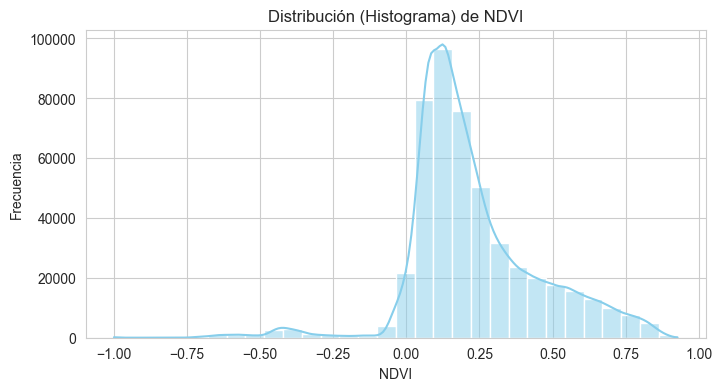

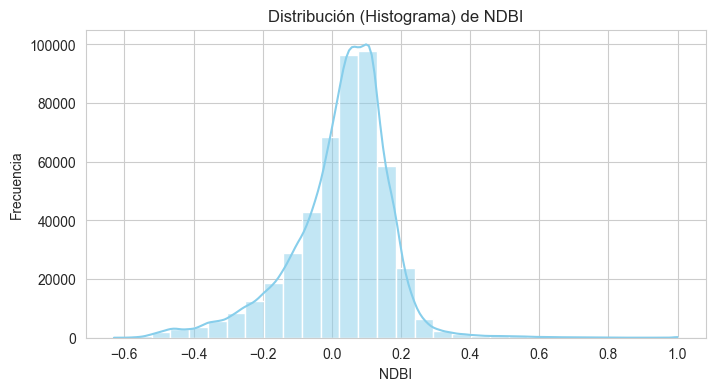

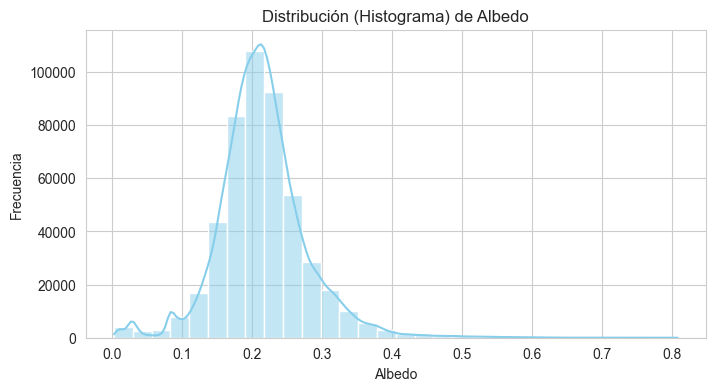

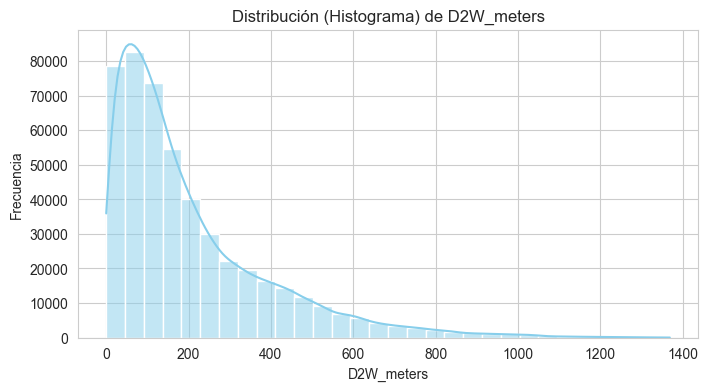

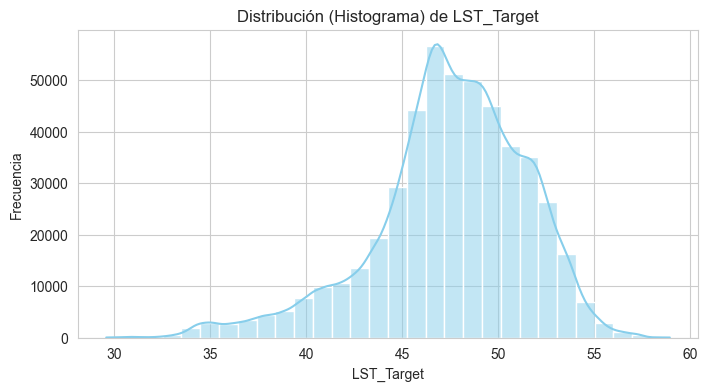


=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===


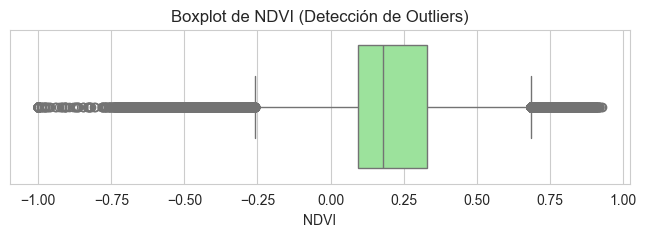

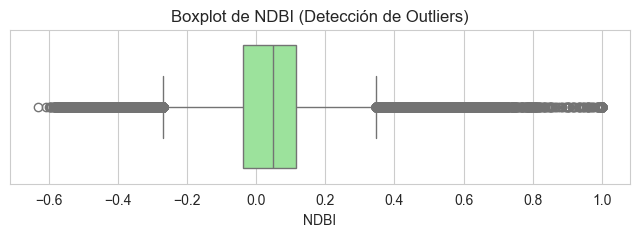

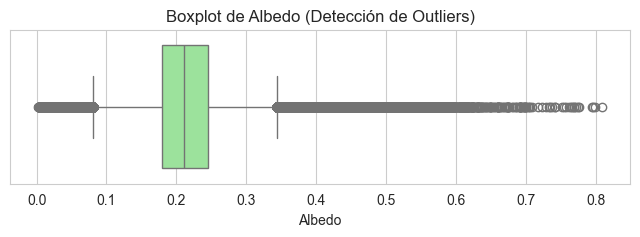

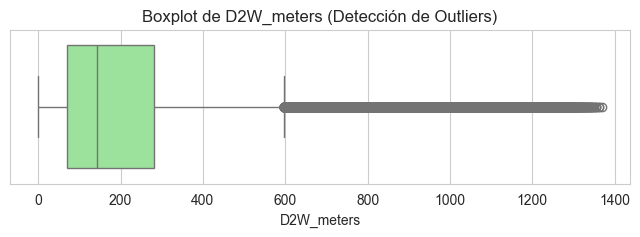

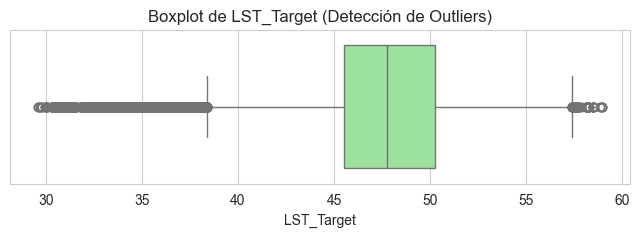


=== 4. DIAGRAMA DE DISPERSIÓN ===


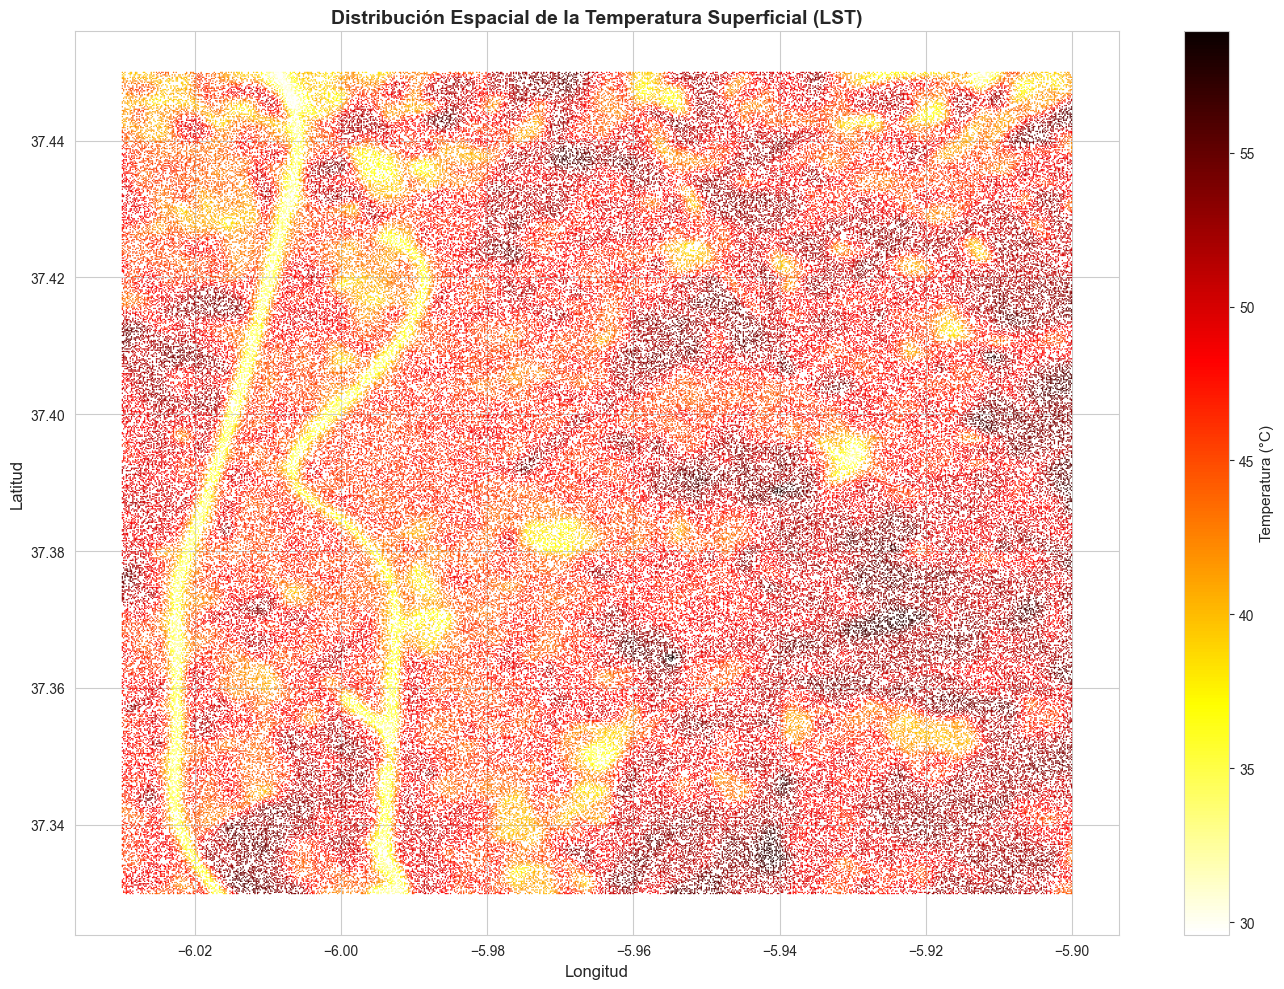


=== 5. ANÁLISIS DE CORRELACIÓN ===


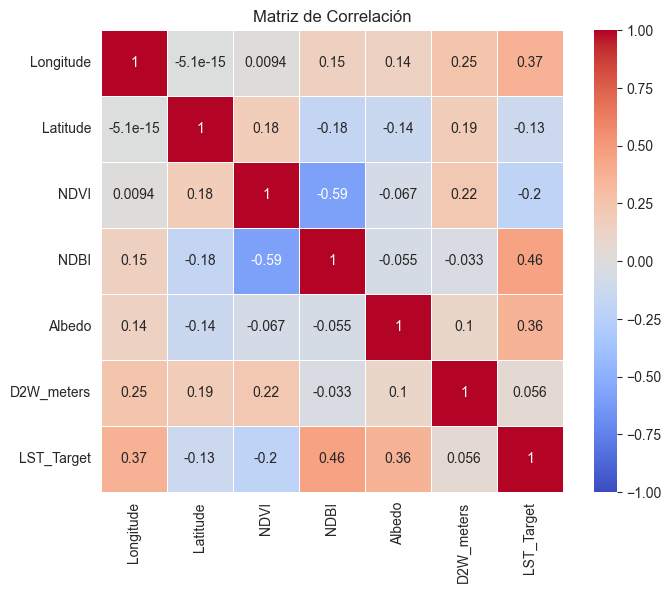

In [23]:
cols_numericas = ['Longitude', 'Latitude', 'NDVI', "NDBI", "Albedo", "D2W_meters", "LST_Target"]
cols_categoricas = []
ignorar_para_distribucion = ['Latitude', 'Longitude']

print("\n=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===")
graficar_distribuciones(df_sevilla_pixels, cols_numericas, cols_categoricas, ignorar_para_distribucion)

print("\n=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===")
detectar_anomalias_boxplots(df_sevilla_pixels, cols_numericas, ignorar_para_distribucion)

print("\n=== 4. DIAGRAMA DE DISPERSIÓN ===")
graficar_mapa_densidad(
    df=df_sevilla_pixels
)

print("\n=== 5. ANÁLISIS DE CORRELACIÓN ===")
analisis_correlacion(df_sevilla_pixels)

## Edificios

In [ ]:
CSV_PATH_EDIFICIOS = datasets_local["edificios"]
df_edificios_sevilla = pd.read_csv(CSV_PATH_EDIFICIOS)
print(f"Dataset cargado: {CSV_PATH_EDIFICIOS}")
print(f"Dimensiones edificios: {df_edificios_sevilla.shape[0]:,} filas × {df_edificios_sevilla.shape[1]} columnas")

In [24]:
print("=== 1. IDENTIFICACIÓN GENERAL ===")
identificar_valores_nulos_y_tipos(df_edificios_sevilla)

=== 1. IDENTIFICACIÓN GENERAL ===
--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 29960 entries, 0 to 29959
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id_edificio      29960 non-null  int64  
 1   latitud          29960 non-null  float64
 2   longitud         29960 non-null  float64
 3   altura_estimada  29960 non-null  float64
dtypes: float64(3), int64(1)
memory usage: 936.4 KB
None

--- Valores Nulos por Columna ---
id_edificio        0
latitud            0
longitud           0
altura_estimada    0
dtype: int64

--- Estadísticas Descriptivas ---


,id_edificio,latitud,longitud,altura_estimada
count,2.996000e+04,29960.000000,29960.000000,29960.000000
mean,6.120327e+08,37.389656,-5.985148,8.571018
std,3.692052e+08,0.018760,0.021070,107.388175
min,5.107100e+04,37.329436,-6.030905,0.000000
25%,3.813077e+08,37.379291,-6.000263,6.000000
50%,5.820433e+08,37.388272,-5.989310,6.000000
75%,7.610766e+08,37.400367,-5.975879,6.000000
max,1.526530e+09,37.448815,-5.899298,18462.000000



=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===


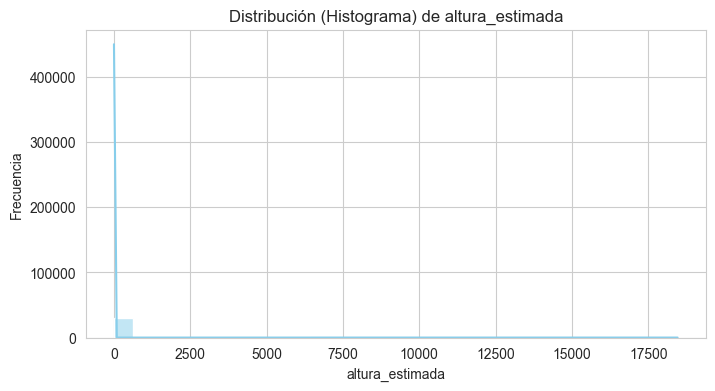


=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===


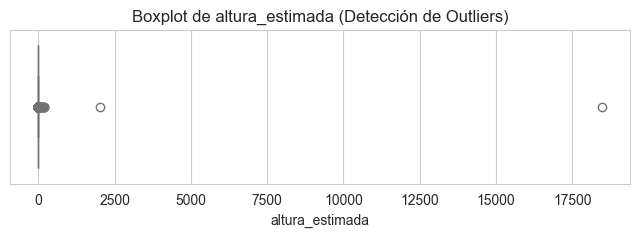


=== 4. DIAGRAMA DE DISPERSIÓN ===



=== 5. ANÁLISIS DE CORRELACIÓN ===

=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===


In [26]:
cols_numericas = ['latitud', 'longitud', 'altura_estimada']
cols_categoricas = []
ignorar_para_distribucion = ['latitud', 'longitud', 'id_edificio']

print("\n=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===")
graficar_distribuciones(df_edificios_sevilla, cols_numericas, cols_categoricas, ignorar_para_distribucion)

print("\n=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===")
detectar_anomalias_boxplots(df_edificios_sevilla, cols_numericas, ignorar_para_distribucion)

print("\n=== 4. DIAGRAMA DE DISPERSIÓN ===")
graficar_dispersion_mapa(
    df=df_edificios_sevilla, 
    col_lat='latitud', 
    col_lon='longitud', 
    col_categoria=None
)

print("\n=== 5. ANÁLISIS DE CORRELACIÓN ===")
print("\n=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===")

## Conclusiones edificios

Podemos ver varias anomalias en esta base de datos, la primera es que el percentil 25% , 50% y 75% tienen exactamente el mismo valor. Por lo que la inmensa mayoria de edicios miden 6, suponemos que metros en la web no revela esa información. Sin embargo que el valor sea 6 en mas de la mitad del dataset, sugiere que son valores por defecto cuando no se conoce la altura real.

Otro dato interesante es que el maximo es 18462, si estamos hablando de metros, son 18KM, un avion comercial vuela más bajo. Por lo que parece un error de medición.

## Carreteras de sevilla

In [ ]:
CSV_PATH_CARRETERAS = datasets_local["carreteras"]
df_carreteras_sevilla = pd.read_csv(CSV_PATH_CARRETERAS)
print(f"Dataset cargado: {CSV_PATH_CARRETERAS}")
print(f"Dimensiones carreteras: {df_carreteras_sevilla.shape[0]:,} filas × {df_carreteras_sevilla.shape[1]} columnas")

In [22]:

print("=== 1. IDENTIFICACIÓN GENERAL ===")
identificar_valores_nulos_y_tipos(df_carreteras_sevilla)

=== 1. IDENTIFICACIÓN GENERAL ===
--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 3182 entries, 0 to 3181
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id_via    3182 non-null   int64  
 1   tipo      3182 non-null   str    
 2   nombre    3182 non-null   str    
 3   latitud   3182 non-null   float64
 4   longitud  3182 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 124.4 KB
None

--- Valores Nulos por Columna ---
id_via      0
tipo        0
nombre      0
latitud     0
longitud    0
dtype: int64

--- Estadísticas Descriptivas ---


,id_via,tipo,nombre,latitud,longitud
count,3.182000e+03,3182,3182,3182.000000,3182.000000
unique,NaN,8,271,NaN,NaN
top,NaN,primary,Sin nombre,NaN,NaN
freq,NaN,1464,995,NaN,NaN
mean,4.323284e+08,NaN,NaN,37.382081,-5.974520
std,4.441655e+08,NaN,NaN,0.025168,0.028129
min,1.023319e+07,NaN,NaN,37.326527,-6.032144
25%,5.772245e+07,NaN,NaN,37.366621,-5.993444
50%,2.578738e+08,NaN,NaN,37.382334,-5.976428
75%,6.411894e+08,NaN,NaN,37.400045,-5.954427



=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===


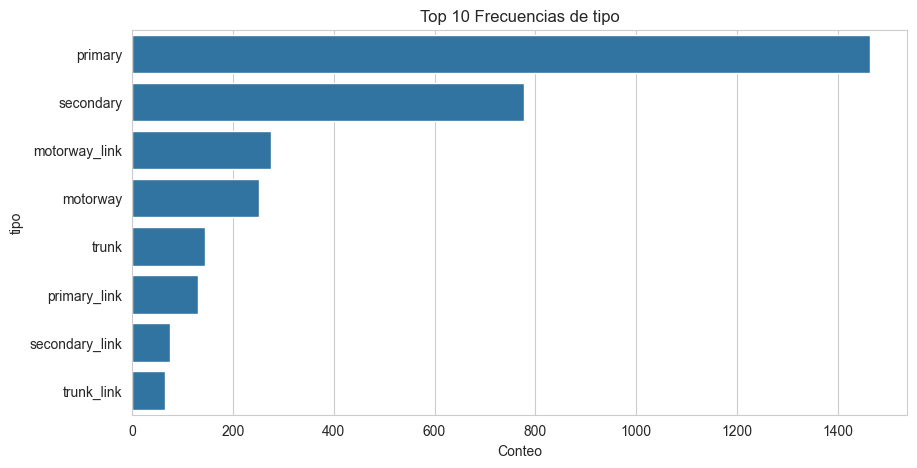


=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===

=== 4. DIAGRAMA DE DISPERSIÓN ===



=== 5. ANÁLISIS DE CORRELACIÓN ===

=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===


In [23]:
cols_numericas = ['latitud', 'longitud']
cols_categoricas = ['tipo']
ignorar_para_distribucion = ['latitud', 'longitud', 'id_via']

print("\n=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===")
graficar_distribuciones(df_carreteras_sevilla, cols_numericas, cols_categoricas, ignorar_para_distribucion)

print("\n=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===")
detectar_anomalias_boxplots(df_carreteras_sevilla, cols_numericas, ignorar_para_distribucion)

print("\n=== 4. DIAGRAMA DE DISPERSIÓN ===")
graficar_dispersion_mapa(
    df=df_carreteras_sevilla, 
    col_lat='latitud', 
    col_lon='longitud', 
    col_categoria=None
)

print("\n=== 5. ANÁLISIS DE CORRELACIÓN ===")
print("\n=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===")

## Conclusiones carreteras

Se observa que existen muchas carreteras (995) marcadas como sin nombre, sin embargo esto no es algo que nos preocupe ya que a priory solo nos interesa el tipo de via y su localización.

También observamos que casi la mitad del dataset esta marcado como primary, y las otras 7 categorias se reparten el resto.

## Arbolado    

In [24]:
CSV_PATH_ARBOLADO = datasets_local["arbolado"]
df_arbolado_sevilla = pd.read_csv(CSV_PATH_ARBOLADO)
print(f"Dataset cargado: {CSV_PATH_ARBOLADO}")
print(f"Dimensiones arbolado: {df_arbolado_sevilla.shape[0]:,} filas × {df_arbolado_sevilla.shape[1]} columnas")

Dataset cargado: ../datasets/raw/arbolado_sevilla.csv
Dimensiones arbolado: 18,054 filas × 4 columnas


=== 1. IDENTIFICACIÓN GENERAL ===
--- Información del Dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 18054 entries, 0 to 18053
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id_arbol  18054 non-null  int64  
 1   especie   18054 non-null  str    
 2   latitud   18054 non-null  float64
 3   longitud  18054 non-null  float64
dtypes: float64(2), int64(1), str(1)
memory usage: 564.3 KB
None

--- Valores Nulos por Columna ---
id_arbol    0
especie     0
latitud     0
longitud    0
dtype: int64

--- Estadísticas Descriptivas ---


,id_arbol,especie,latitud,longitud
count,1.805400e+04,18054,18054.000000,18054.000000
unique,NaN,78,NaN,NaN
top,NaN,desconocida,NaN,NaN
freq,NaN,10490,NaN,NaN
mean,6.792090e+09,NaN,37.392584,-5.980740
std,2.864872e+09,NaN,0.024419,0.022751
min,9.177036e+08,NaN,37.337035,-6.029973
25%,4.895450e+09,NaN,37.379958,-5.997035
50%,6.536115e+09,NaN,37.394786,-5.986482
75%,7.468396e+09,NaN,37.414521,-5.966412


=== 1.1 RESUMEN DE CATEGORÍAS ===
Conteo de categorías para 'especie' (total: 18054):
- desconocida: 10490 (58.10%)
- broadleaved: 3294 (18.25%)
- Citrus × aurantium: 2359 (13.07%)
- Platanus × hispanica: 498 (2.76%)
- Phoenix dactylifera: 378 (2.09%)
- Brachychiton populneus: 177 (0.98%)
- needleleaved: 134 (0.74%)
- Pinus SPP.: 78 (0.43%)
- palm: 76 (0.42%)
- Citrus aurantium: 65 (0.36%)
- Schinus areira: 47 (0.26%)
- Jacaranda: 46 (0.25%)
- Phoenix canariensis: 46 (0.25%)
- Tipuana: 41 (0.23%)
- Washingtonia filifera: 28 (0.16%)
- Eucalyptus melliodora: 27 (0.15%)
- Cupressus: 26 (0.14%)
- Jacaranda mimosifolia: 20 (0.11%)
- Melia azedarach: 20 (0.11%)
- Olea europaea: 18 (0.10%)
- Citrus myrtifolia: 15 (0.08%)
- Trachycarpus fortunei: 13 (0.07%)
- Washingtonia robusta: 13 (0.07%)
- Magniliopsida: 12 (0.07%)
- Ficus: 11 (0.06%)
- Citrus: 10 (0.06%)
- Chamaerops humilis: 9 (0.05%)
- Yucca sp: 8 (0.04%)
- Fraxinus excelsior: 8 (0.04%)
- Phytolacca dioica L.: 6 (0.03%)
- Celtis austral

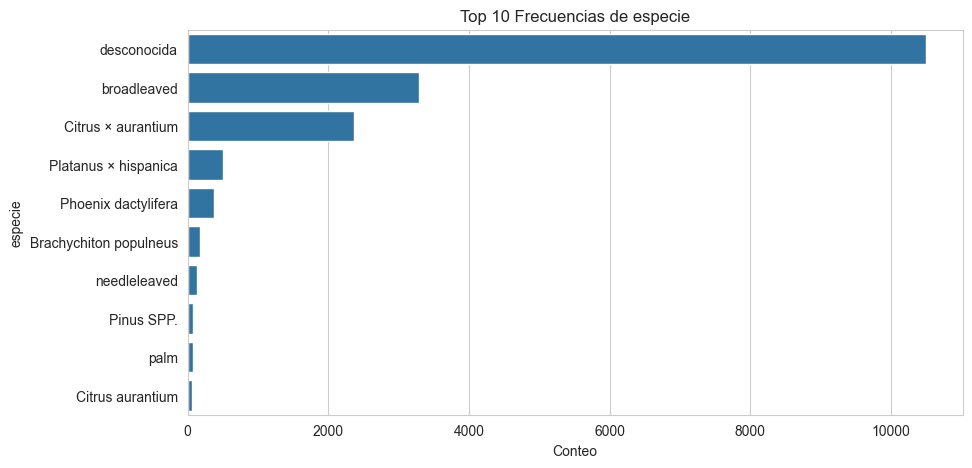


=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===

=== 4. DIAGRAMA DE DISPERSIÓN ===



=== 5. ANÁLISIS DE CORRELACIÓN ===

=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===


In [32]:
cols_numericas = ['latitud', 'longitud']
cols_categoricas = ['especie']
ignorar_para_distribucion = ['latitud', 'longitud', 'id_arbol']

# 3. Ejecutar el pipeline de análisis usando las funciones

print("=== 1. IDENTIFICACIÓN GENERAL ===")
identificar_valores_nulos_y_tipos(df_arbolado_sevilla)

print("=== 1.1 RESUMEN DE CATEGORÍAS ===")
resumir_conteo_categorias(df_arbolado_sevilla, 'especie')

print("\n=== 2. DISTRIBUCIONES (HISTOGRAMAS Y BARRAS) ===")
graficar_distribuciones(df_arbolado_sevilla, cols_numericas, cols_categoricas, ignorar_para_distribucion)

print("\n=== 3. ANOMALÍAS Y VALORES ATÍPICOS (BOXPLOTS) ===")
detectar_anomalias_boxplots(df_arbolado_sevilla, cols_numericas, ignorar_para_distribucion)

print("\n=== 4. DIAGRAMA DE DISPERSIÓN ===")
graficar_dispersion_mapa(
    df=df_arbolado_sevilla, 
    col_lat='latitud', 
    col_lon='longitud', 
    col_categoria='especie'
)

print("\n=== 5. ANÁLISIS DE CORRELACIÓN ===")
print("\n=== No tiene sentido ya que las variables numericas son la latitud y longitud y el id ===")


## Conclusiones arbolado

Lo primero que podemos observar es que mas de la mitad del dataset tiene el arbol marcado como "Desconocida".

Podemos ver tambien que existen 78 especies distintas.
